In [ ]:
import kagglehub
yogeshm01_india_air_quality_dataset_20252026_path = kagglehub.dataset_download('yogeshm01/india-air-quality-dataset-20252026')


Using Colab cache for faster access to the 'india-air-quality-dataset-20252026' dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
df = pd.read_csv(f"{yogeshm01_india_air_quality_dataset_20252026_path}/enriched_aqi_dataset.csv")

print("Shape of dataset:", df.shape)
df.head(10)

Shape of dataset: (10521, 22)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer
5,India,Andhra Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",2026-07-01 23:00:00.000000000,13.670000,79.350000,SO2,4.0,10.0,...,Good,15.9,46.9,16.4,2026,7,1,23,2,Summer
6,India,Andhra Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",2026-07-01 23:00:00.000000000,13.670000,79.350000,CO,12.0,22.0,...,Good,37.8,34.3,4.8,2026,7,1,23,2,Summer
7,India,Andhra Pradesh,Tirupati,"Vaikuntapuram, Tirupati - APPCB",2026-07-01 23:00:00.000000000,13.615387,79.409230,PM2.5,32.0,46.0,...,Good,31.3,86.2,21.8,2026,7,1,23,2,Summer
8,India,Andhra Pradesh,Tirupati,"Vaikuntapuram, Tirupati - APPCB",2026-07-01 23:00:00.000000000,13.615387,79.409230,PM10,55.0,66.0,...,Moderate,26.6,92.5,14.1,2026,7,1,23,2,Summer
9,India,Andhra Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",2026-07-01 23:00:00.000000000,16.509717,80.612222,PM2.5,47.0,87.0,...,Moderate,31.2,76.2,7.8,2026,7,1,23,2,Summer


| Category | Feature (English) | Feature (Arabic) | Description (Arabic) |
| :--- | :--- | :--- | :--- |
| Location & Geography | country | البلد | Name of the country (all India). |
| Location & Geography | state | الولاية | Name of the state in India. |
| Location & Geography | city | المدينة | Name of the city in the specified state. |
| Location & Geography | station | المحطة | Name of the air quality monitoring station. |
| Location & Geography | latitude | خط العرض | Geographical latitude of the station. |
| Location & Geography | longitude | خط الطول | Geographical longitude of the station. |
| Time & Date | last_update | آخر تحديث | Date and time of the last air quality data update. |
| Time & Date | Year | السنة | Year of data collection. |
| Time & Date | Month | الشهر | Month of data collection. |
| Time & Date | Day | اليوم | Day of data collection. |
| Time & Date | Hour | الساعة | Hour of data collection. |
| Time & Date | Day_of_Week | يوم الأسبوع | Day of the week as a numerical code (0-6). |
| Time & Date | Season | الموسم | Climatic season (e.g., Summer, Winter). |
| Air Quality & Pollutants | pollutant_id | معرف الملوث | Type of pollutant (e.g., PM2.5, NO2, OZONE). |
| Air Quality & Pollutants | pollutant_min | أدنى ملوث | Minimum pollutant concentration. |
| Air Quality & Pollutants | pollutant_max | أقصى ملوث | Maximum pollutant concentration. |
| Air Quality & Pollutants | pollutant_avg | متوسط الملوث | Average pollutant concentration. |
| Air Quality & Pollutants | AQI | مؤشر جودة الهواء | Unified numerical value for air quality. |
| Air Quality & Pollutants | AQI_Bucket | فئة مؤشر جودة الهواء | Descriptive classification (e.g., Good, Moderate, Bad). |
| Weather Factors | Temperature_C | درجة الحرارة مئوية | Temperature in Celsius degrees. |
| Weather Factors | Humidity_% | الرطوبة % | Percentage of humidity in the air. |
| Weather Factors | Wind_Speed_kmh | سرعة الرياح كم/س | Wind speed in kilometers per hour.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  object 
 1   state           10521 non-null  object 
 2   city            10521 non-null  object 
 3   station         10521 non-null  object 
 4   last_update     10521 non-null  object 
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  object 
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  object 
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year            10521 non-null  int64  
 17  Month           10521 non-null 

In [ ]:
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,357
pollutant_max,357


In [ ]:
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg,AQI,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week
count,10521.000000,10521.000000,10164.000000,10164.000000,10164.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000
mean,21.970147,81.228132,50.536787,233.356966,100.840329,118.237430,27.584621,62.351250,15.071875,2025.986693,6.670374,10.797453,15.327535,2.668092
std,6.798401,6.560283,53.954573,161.227762,81.948059,103.562225,7.231523,18.940531,8.673204,0.669696,2.813108,9.957950,7.882064,1.684897
min,8.514909,70.776774,0.000000,0.000000,0.000000,0.000000,15.000000,30.000000,0.000000,2025.000000,1.000000,1.000000,0.000000,0.000000
25%,16.690571,75.905894,10.000000,62.000000,26.000000,33.000000,21.300000,45.900000,7.600000,2026.000000,5.000000,1.000000,8.000000,2.000000
50%,22.568732,79.946728,29.250000,247.850000,80.600000,89.000000,27.600000,62.200000,15.100000,2026.000000,7.000000,8.000000,18.000000,2.000000
75%,27.759769,86.590325,74.200000,377.225000,170.400000,183.000000,33.900000,79.000000,22.700000,2026.000000,8.000000,19.000000,23.000000,4.000000
max,34.066206,94.636574,262.000000,500.000000,266.000000,499.000000,40.000000,95.000000,30.000000,2027.000000,12.000000,31.000000,23.000000,6.000000


## Data Cleaning and Preparation

### 1. Handling Missing Values

In [ ]:
for col in ['pollutant_min', 'pollutant_max', 'pollutant_avg']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

print(df.isnull().sum())

country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
pollutant_min     0
pollutant_max     0
pollutant_avg     0
AQI               0
AQI_Bucket        0
Temperature_C     0
Humidity_%        0
Wind_Speed_kmh    0
Year              0
Month             0
Day               0
Hour              0
Day_of_Week       0
Season            0
dtype: int64


/tmp/ipykernel_3812/4000626301.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [122]:
df['last_update'] = pd.to_datetime(df['last_update'])

In [ ]:
df.groupby("AQI_Bucket")["AQI"].agg(["min", "max"])

,min,max
AQI_Bucket,,
Good,0,50
Hazardous,301,499
Moderate,51,100
Unhealthy,151,200
Unhealthy for Sensitive Groups,101,150
Very Unhealthy,201,300


In [ ]:

drop_cols = ["AQI", "country", "city", "station", "last_update", "latitude", "longitude", "date"]

target = "AQI_Bucket"
feature_cols = [c for c in df.columns if c not in drop_cols + [target]]
print("Features used for modeling:")
print(feature_cols)

Features used for modeling:
['state', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg', 'Temperature_C', 'Humidity_%', 'Wind_Speed_kmh', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Season']


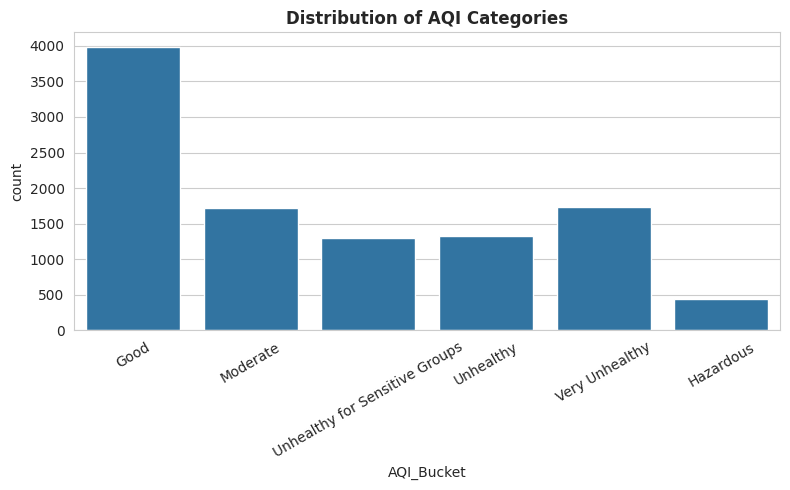

In [ ]:
plt.figure(figsize=(8,5))
order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]
sns.countplot(data=df, x="AQI_Bucket", order=order)
plt.title("Distribution of AQI Categories",fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

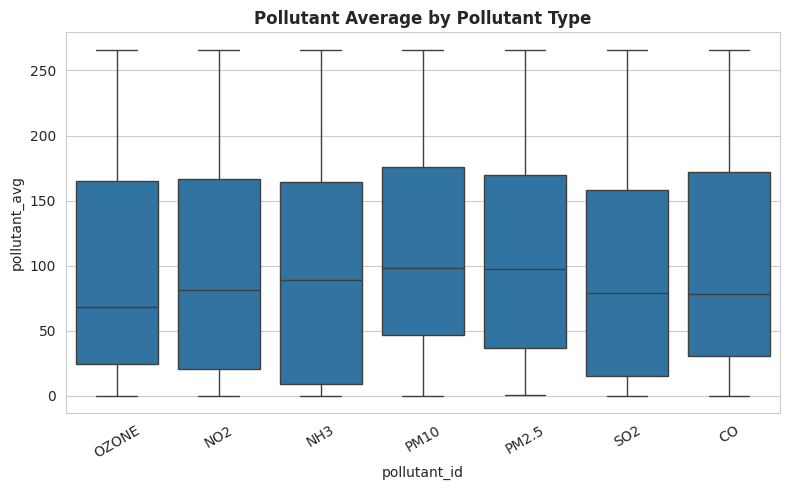

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="pollutant_id", y="pollutant_avg")
plt.title("Pollutant Average by Pollutant Type",fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

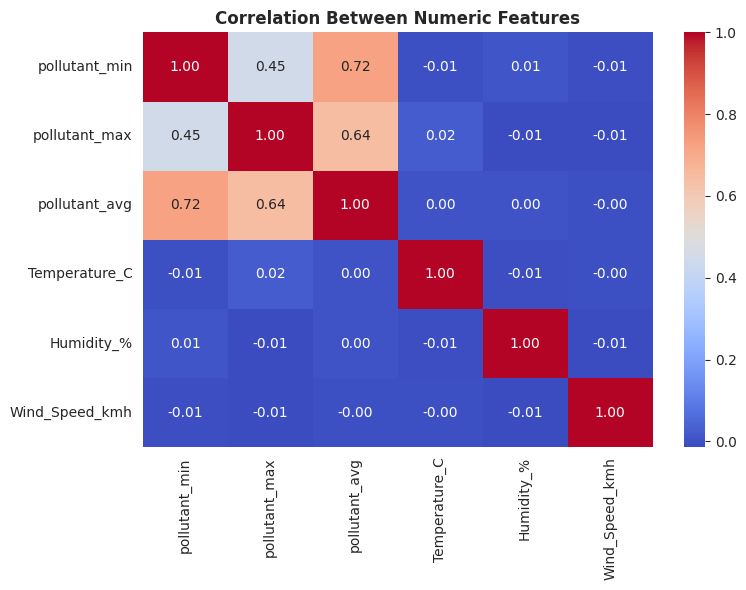

In [ ]:
plt.figure(figsize=(8,6))
numeric_cols = ["pollutant_min", "pollutant_max", "pollutant_avg", "Temperature_C", "Humidity_%", "Wind_Speed_kmh"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features",fontweight='bold')
plt.tight_layout()
plt.show()

### Average Monthly AQI

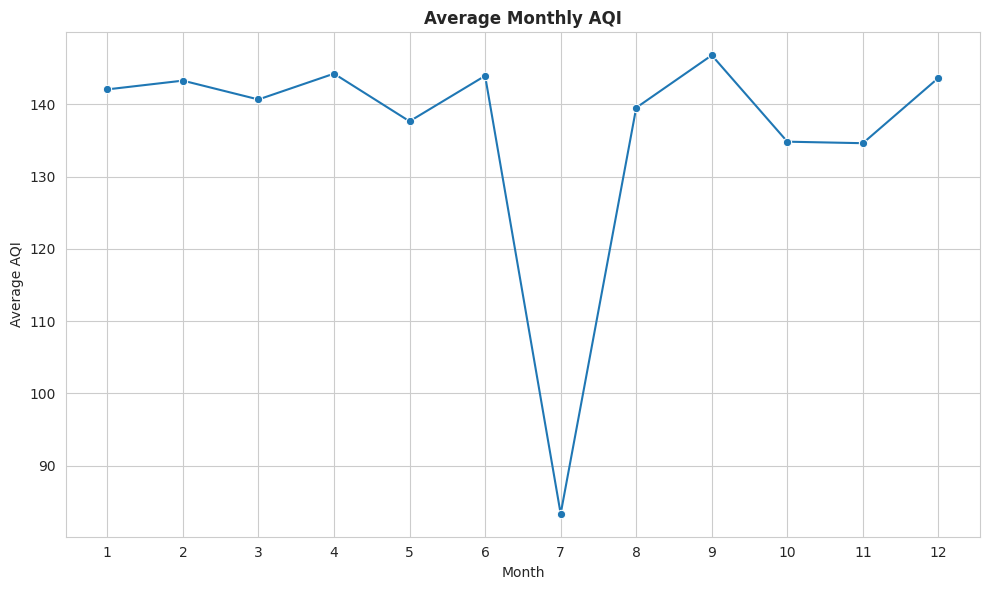

In [123]:
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_aqi, x='Month', y='AQI', marker='o')
plt.title('Average Monthly AQI', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

### Average AQI by State

/tmp/ipykernel_3812/3878218955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_aqi, x='AQI', y='state', palette='viridis')


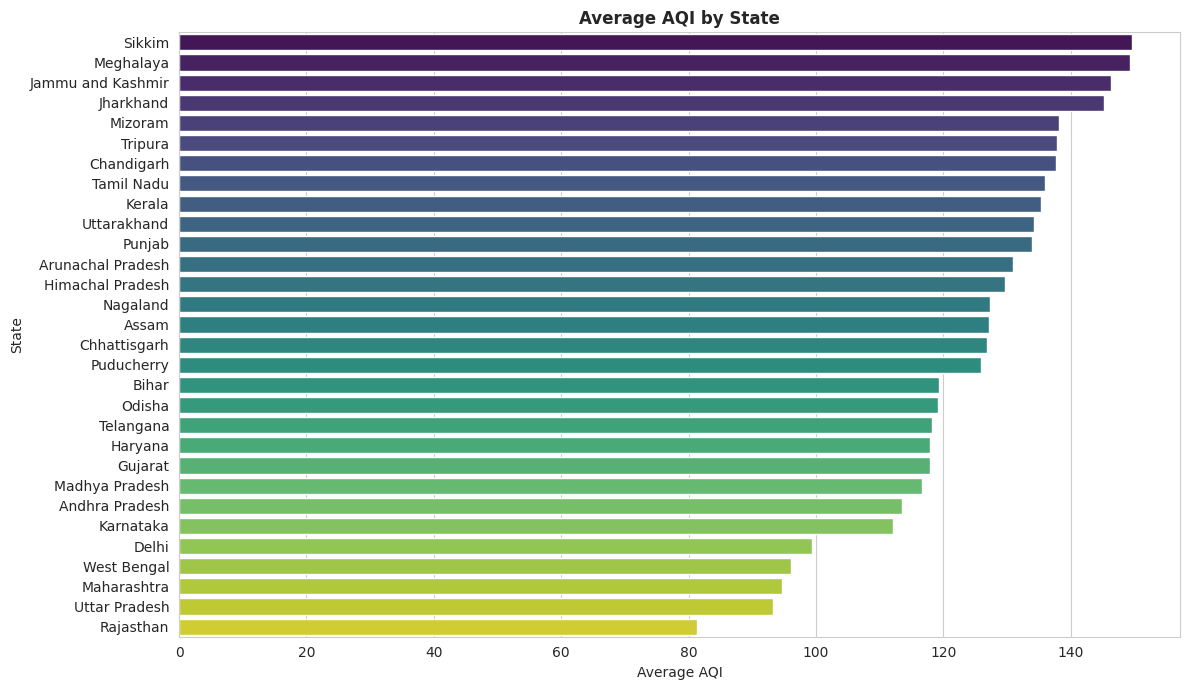

In [124]:
state_aqi = df.groupby('state')['AQI'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=state_aqi, x='AQI', y='state', palette='viridis')
plt.title('Average AQI by State', fontweight='bold')
plt.xlabel('Average AQI')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [ ]:
X = df[feature_cols].copy()
y = df[target].copy()

encoders = {}
for col in ["state", "pollutant_id", "Season"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

,state,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,0,3,39.0,41.0,40.0,23.8,68.2,10.6,2026,7,1,23,2,2
1,0,2,13.0,33.0,18.0,30.6,60.3,19.1,2026,7,1,23,2,2
2,0,1,3.0,5.0,4.0,28.4,44.3,8.8,2026,7,1,23,2,2
3,0,4,45.0,106.0,66.0,39.6,38.9,2.5,2026,7,1,23,2,2
4,0,5,5.0,19.0,11.0,21.4,47.7,28.3,2026,7,1,23,2,2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8416
Testing samples: 2105


In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


model.fit(X_train, y_train)
print("Model training complete!")



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    5.7s


Model training complete!


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    7.8s finished


In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s


✅ Accuracy: 0.9914 (99.14%)

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00       798
                     Hazardous       1.00      0.82      0.90        89
                      Moderate       0.99      1.00      0.99       345
                     Unhealthy       0.98      0.99      0.99       265
Unhealthy for Sensitive Groups       0.98      1.00      0.99       259
                Very Unhealthy       1.00      1.00      1.00       349

                      accuracy                           0.99      2105
                     macro avg       0.99      0.97      0.98      2105
                  weighted avg       0.99      0.99      0.99      2105



[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.2s finished


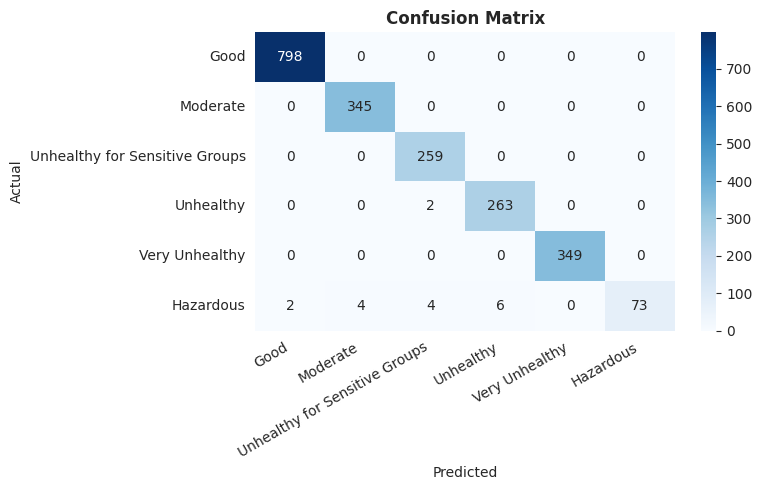

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=order)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix",fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

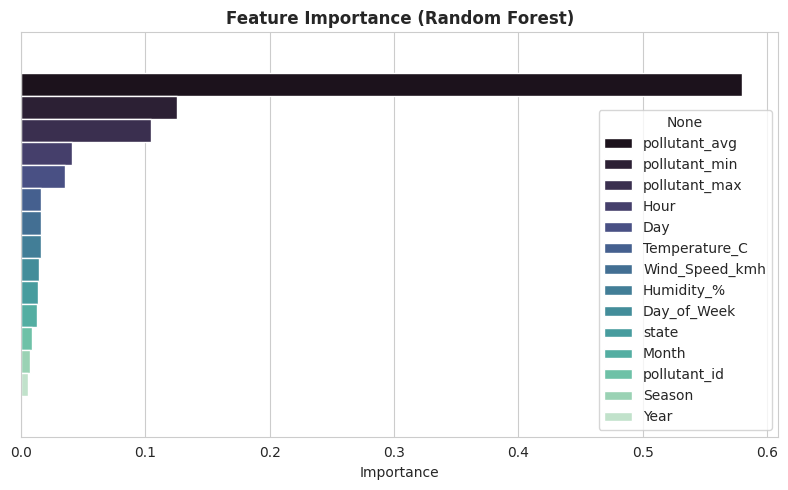

,0
pollutant_avg,0.580310
pollutant_min,0.125908
pollutant_max,0.104538
Hour,0.041263
Day,0.035656
Temperature_C,0.016484
Wind_Speed_kmh,0.016325
Humidity_%,0.016200
Day_of_Week,0.014222
state,0.013426


In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, hue=importances.index, palette="mako")
plt.title("Feature Importance (Random Forest)",fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the GradientBoostingClassifier
gbc_model = GradientBoostingClassifier(
    n_estimators=300, # Number of boosting stages to perform
    learning_rate=0.1, # Step size shrinkage to prevent overfitting
    max_depth=5, # Maximum depth of the individual regression estimators
    random_state=42,
    verbose=1
)

# Train the model
gbc_model.fit(X_train, y_train)
print("Gradient Boosting Model training complete!")

      Iter       Train Loss   Remaining Time 
         1           1.1536            1.08m
         2           0.9119            1.33m
         3           0.7363            1.67m
         4           0.6040            1.85m
         5           0.4970            2.05m
         6           0.4128            2.08m
         7           0.3447            2.11m
         8           0.2885            2.16m
         9           0.2422            2.27m
        10           0.2036            2.25m
        20           0.0378            2.46m
        30           0.0071            2.24m
        40           0.0013            2.02m
        50           0.0003            1.76m
        60           0.0000            1.56m
        70           0.0000            1.38m
        80           0.0000            1.22m
        90           0.0000            1.09m
       100           0.0000           57.84s
       200           0.0000           15.02s
       300           0.0000            0.00s
Gradient 


Gradient Boosting Model Evaluation:
Accuracy: 0.9990
Classification Report:
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00       798
                     Hazardous       1.00      0.98      0.99        89
                      Moderate       1.00      1.00      1.00       345
                     Unhealthy       1.00      1.00      1.00       265
Unhealthy for Sensitive Groups       1.00      1.00      1.00       259
                Very Unhealthy       1.00      1.00      1.00       349

                      accuracy                           1.00      2105
                     macro avg       1.00      1.00      1.00      2105
                  weighted avg       1.00      1.00      1.00      2105



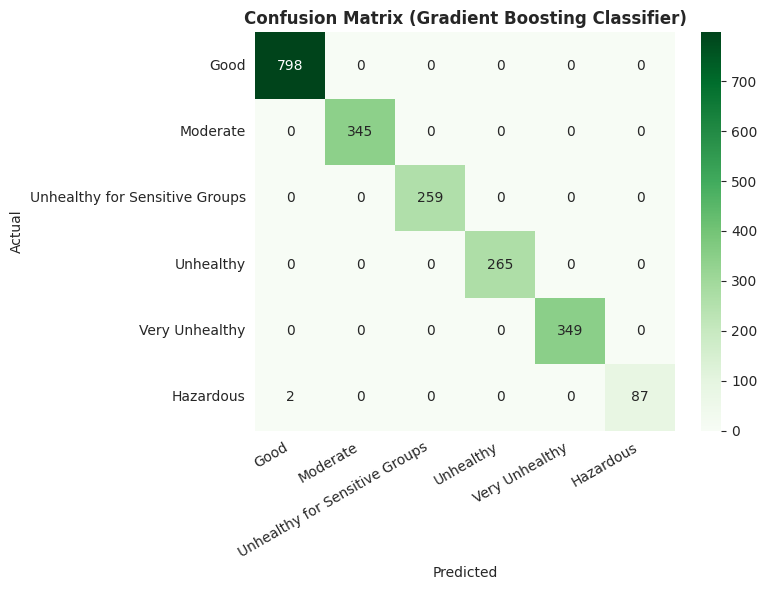

In [ ]:
# Make predictions with the Gradient Boosting Classifier
y_pred_gbc = gbc_model.predict(X_test)

# Evaluate the Gradient Boosting Classifier model
print("\nGradient Boosting Model Evaluation:")
acc_gbc = accuracy_score(y_test, y_pred_gbc)
print(f"Accuracy: {acc_gbc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_gbc))

# Confusion Matrix for GBC
cm_gbc = confusion_matrix(y_test, y_pred_gbc, labels=order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbc, annot=True, fmt="d", cmap="Greens", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix (Gradient Boosting Classifier)", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svc_model = make_pipeline(StandardScaler(), LinearSVC(random_state=42, verbose=1))

# Train the model
svc_model.fit(X_train, y_train)
print("Support Vector Machine (LinearSVC) model training complete!")

[LibLinear]Support Vector Machine (LinearSVC) model training complete!



Support Vector Machine (LinearSVC) Model Evaluation:
Accuracy: 0.8181
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.96      1.00      0.98       798
                     Hazardous       0.45      0.82      0.58        89
                      Moderate       0.66      0.77      0.71       345
                     Unhealthy       0.70      0.83      0.76       265
Unhealthy for Sensitive Groups       0.65      0.07      0.12       259
                Very Unhealthy       0.93      1.00      0.97       349

                      accuracy                           0.82      2105
                     macro avg       0.73      0.75      0.69      2105
                  weighted avg       0.82      0.82      0.78      2105



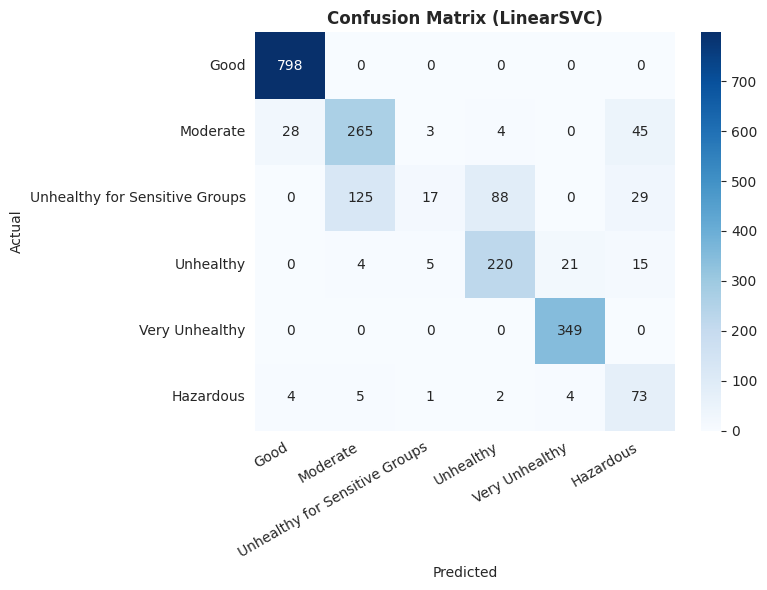

In [ ]:
# Make predictions with the LinearSVC model
y_pred_svc = svc_model.predict(X_test)

# Evaluate the LinearSVC model
print("\nSupport Vector Machine (LinearSVC) Model Evaluation:")
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy: {acc_svc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

# Confusion Matrix for LinearSVC
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix (LinearSVC)", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # Using 5 neighbors as a common starting point

# Train the model
knn_model.fit(X_train, y_train)
print("K-Nearest Neighbors (KNN) model training complete!")

K-Nearest Neighbors (KNN) model training complete!



K-Nearest Neighbors (KNN) Model Evaluation:
Accuracy: 0.9373
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.98      0.99      0.98       798
                     Hazardous       0.86      0.82      0.84        89
                      Moderate       0.91      0.92      0.92       345
                     Unhealthy       0.88      0.89      0.89       265
Unhealthy for Sensitive Groups       0.90      0.85      0.88       259
                Very Unhealthy       0.96      0.96      0.96       349

                      accuracy                           0.94      2105
                     macro avg       0.91      0.91      0.91      2105
                  weighted avg       0.94      0.94      0.94      2105



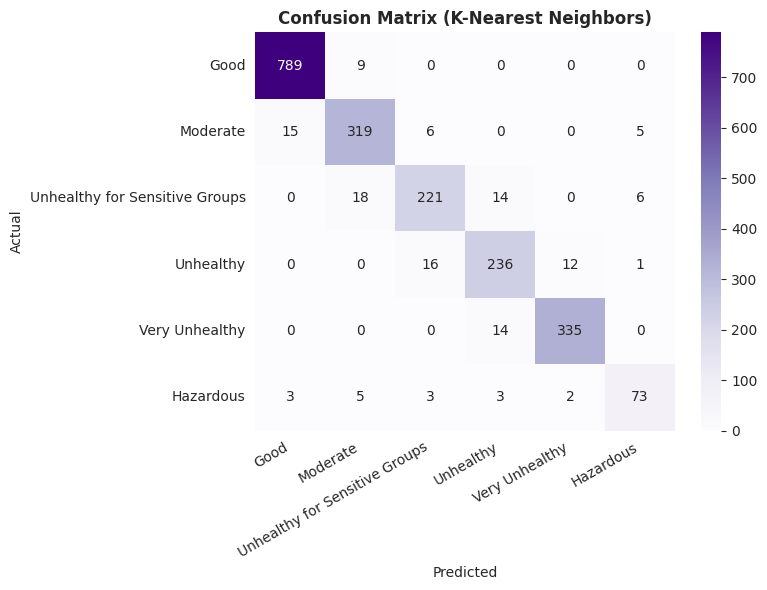

In [ ]:
# Make predictions with the KNN model
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
print("\nK-Nearest Neighbors (KNN) Model Evaluation:")
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc_knn:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Purples", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix (K-Nearest Neighbors)", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Initialize LogisticRegression. It's good practice to scale data for linear models.
# We'll use a pipeline for convenience to apply scaling and then Logistic Regression.
# 'max_iter' is increased for convergence for this dataset.
lr_model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, verbose=1))

# Train the model
lr_model.fit(X_train, y_train)
print("Logistic Regression model training complete!")

[LibLinear]Logistic Regression model training complete!



Logistic Regression Model Evaluation:
Accuracy: 0.8166
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.92      1.00      0.96       798
                     Hazardous       0.50      0.82      0.62        89
                      Moderate       0.66      0.72      0.69       345
                     Unhealthy       0.82      0.68      0.74       265
Unhealthy for Sensitive Groups       0.73      0.27      0.39       259
                Very Unhealthy       0.88      1.00      0.93       349

                      accuracy                           0.82      2105
                     macro avg       0.75      0.75      0.72      2105
                  weighted avg       0.82      0.82      0.80      2105



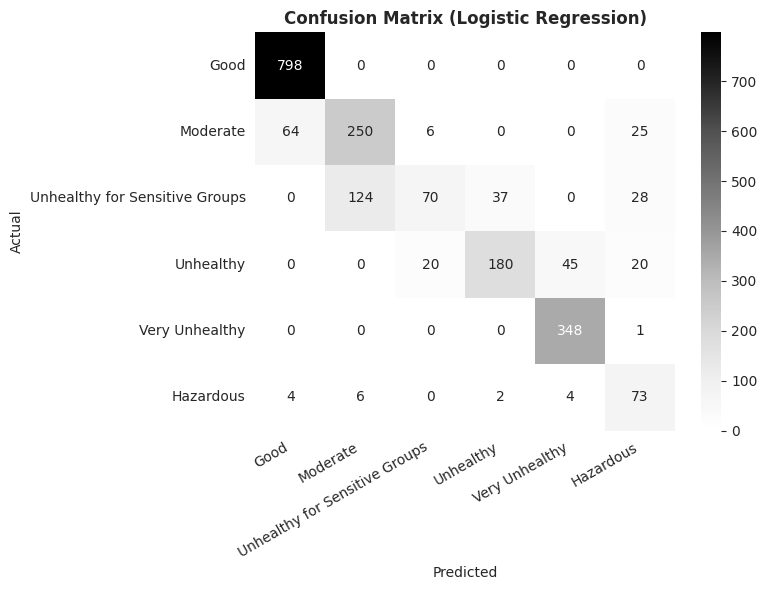

In [ ]:
# Make predictions with the Logistic Regression model
y_pred_lr = lr_model.predict(X_test)

# Evaluate the Logistic Regression model
print("\nLogistic Regression Model Evaluation:")
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greys", xticklabels=order, yticklabels=order)
plt.title("Confusion Matrix (Logistic Regression)", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:


new_data_point = pd.DataFrame({
    'state': [encoders['state'].transform(['Delhi'])[0]], # Example: Delhi
    'pollutant_id': [encoders['pollutant_id'].transform(['PM2.5'])[0]], # Example: PM2.5
    'pollutant_min': [50.0],
    'pollutant_max': [150.0],
    'pollutant_avg': [100.0],
    'Temperature_C': [25.0],
    'Humidity_%': [70.0],
    'Wind_Speed_kmh': [10.0],
    'Year': [2027],
    'Month': [1],
    'Day': [15],
    'Hour': [12],
    'Day_of_Week': [3],
    'Season': [encoders['Season'].transform(['Winter'])[0]] # Example: Winter
})

print("Hypothetical new data point for prediction:")
display(new_data_point)

# Make a prediction using the Gradient Boosting Classifier
predicted_aqi_bucket = gbc_model.predict(new_data_point)

print(f"\nPredicted AQI Bucket for the new data point: {predicted_aqi_bucket[0]}")

Hypothetical new data point for prediction:


,state,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,6,5,50.0,150.0,100.0,25.0,70.0,10.0,2027,1,15,12,3,3



Predicted AQI Bucket for the new data point: Moderate


## مقارنة أداء النماذج

لنلخص أداء جميع النماذج التي قمنا بتدريبها في جدول واحد لمقارنتها بسهولة:

In [127]:
model_accuracies = {
    'Random Forest Classifier': acc,
    'Gradient Boosting Classifier': acc_gbc,
    'LinearSVC': acc_svc,
    'K-Nearest Neighbors': acc_knn,
    'Logistic Regression': acc_lr
}

# Create a DataFrame from the accuracies
model_comparison_df = pd.DataFrame(
    list(model_accuracies.items()),
    columns=['Model', 'Accuracy']
)

# Sort by accuracy for better comparison
model_comparison_df = model_comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(model_comparison_df)

,Model,Accuracy
0,Gradient Boosting Classifier,0.999050
1,Random Forest Classifier,0.991449
2,K-Nearest Neighbors,0.937292
3,LinearSVC,0.818052
4,Logistic Regression,0.816627


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified K-Fold Cross-Validation
# n_splits=5 means the data will be split into 5 parts, and the model will be trained 5 times.
# shuffle=True and random_state=42 ensure reproducibility of the splits.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the Gradient Boosting Classifier
# X and y here represent the full dataset before the initial train-test split for a more comprehensive CV.
# We use the 'accuracy' scoring metric.
print("Performing 5-fold Stratified Cross-Validation on Gradient Boosting Classifier...")
cv_scores = cross_val_score(gbc_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\nCross-validated Accuracy Scores: {cv_scores}")
print(f"Mean Cross-validated Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Performing 5-fold Stratified Cross-Validation on Gradient Boosting Classifier...

Cross-validated Accuracy Scores: [1. 1. 1. 1. 1.]
Mean Cross-validated Accuracy: 1.0000 (+/- 0.0000)


## Creating a Streamlit App

In [ ]:
# Install Streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.0 MB/s eta 0:00:00


Now, let's create the `app.py` file for our Streamlit application. This file will contain the code for the UI and model prediction logic. We will save the trained model and encoders first to be loaded by the Streamlit app.

In [ ]:
import joblib

# Save the trained Gradient Boosting Classifier model
joblib.dump(gbc_model, 'gbc_model.pkl')

# Save the encoders dictionary
joblib.dump(encoders, 'encoders.pkl')

print("Model and encoders saved successfully.")

Model and encoders saved successfully.


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model and encoders
gbc_model = joblib.load('gbc_model.pkl')
encoders = joblib.load('encoders.pkl')

# Define the order of AQI Buckets for consistency
aqi_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]

st.set_page_config(layout="wide")
st.title("India Air Quality Prediction")
st.markdown("This app predicts the AQI Bucket based on various environmental and time-series features.")

# Create input widgets for each feature
st.sidebar.header("Input Features")

def user_input_features():
    state = st.sidebar.selectbox('State', encoders['state'].classes_)
    pollutant_id = st.sidebar.selectbox('Pollutant ID', encoders['pollutant_id'].classes_)
    pollutant_min = st.sidebar.slider('Pollutant Min', 0.0, 500.0, 50.0)
    pollutant_max = st.sidebar.slider('Pollutant Max', 0.0, 500.0, 150.0)
    pollutant_avg = st.sidebar.slider('Pollutant Avg', 0.0, 500.0, 100.0)
    temperature_c = st.sidebar.slider('Temperature (°C)', 0.0, 50.0, 25.0)
    humidity_percent = st.sidebar.slider('Humidity (%)', 0.0, 100.0, 70.0)
    wind_speed_kmh = st.sidebar.slider('Wind Speed (km/h)', 0.0, 50.0, 10.0)
    year = st.sidebar.slider('Year', 2025, 2030, 2027)
    month = st.sidebar.slider('Month', 1, 12, 1)
    day = st.sidebar.slider('Day', 1, 31, 15)
    hour = st.sidebar.slider('Hour', 0, 23, 12)
    day_of_week = st.sidebar.slider('Day of Week (0=Monday, 6=Sunday)', 0, 6, 3)
    season = st.sidebar.selectbox('Season', encoders['Season'].classes_)

    data = {
        'state': state,
        'pollutant_id': pollutant_id,
        'pollutant_min': pollutant_min,
        'pollutant_max': pollutant_max,
        'pollutant_avg': pollutant_avg,
        'Temperature_C': temperature_c,
        'Humidity_%': humidity_percent,
        'Wind_Speed_kmh': wind_speed_kmh,
        'Year': year,
        'Month': month,
        'Day': day,
        'Hour': hour,
        'Day_of_Week': day_of_week,
        'Season': season
    }
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader('User Input Features')
st.write(input_df)

# Apply Label Encoding to user input
for col in ["state", "pollutant_id", "Season"]:
    if col in input_df.columns:
        # Ensure the input value is in the classes known by the encoder
        # If not, handle it (e.g., use a default, or raise an error)
        # For simplicity, we'll assume valid inputs based on selectbox options.
        encoded_value = encoders[col].transform([input_df[col].iloc[0]])[0]
        input_df[col] = encoded_value

# Make prediction
if st.sidebar.button('Predict AQI Bucket'):
    prediction = gbc_model.predict(input_df)
    prediction_proba = gbc_model.predict_proba(input_df)

    st.subheader('Prediction')
    predicted_bucket = prediction[0]
    st.success(f"The Predicted AQI Bucket is: **{predicted_bucket}**")

    st.subheader('Prediction Probability')
    proba_df = pd.DataFrame(prediction_proba, columns=gbc_model.classes_)
    proba_df = proba_df[aqi_order] # Order columns for better display
    st.bar_chart(proba_df.iloc[0])
    st.write(proba_df)



Writing app.py


In [120]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import sys
import traceback

# Load the trained model and encoders
try:
    gbc_model = joblib.load('gbc_model.pkl')
    encoders = joblib.load('encoders.pkl')
except Exception as e:
    st.error(f"Error loading model or encoders: {e}")
    st.stop()

# Define the order of AQI Buckets for consistency
aqi_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]

st.set_page_config(layout="wide")
st.title("India Air Quality Prediction")
st.markdown("This app predicts the AQI Bucket based on various environmental and time-series features.")

# Create input widgets for each feature
st.sidebar.header("Input Features")

def user_input_features():
    state = st.sidebar.selectbox('State', encoders['state'].classes_)
    pollutant_id = st.sidebar.selectbox('Pollutant ID', encoders['pollutant_id'].classes_)
    pollutant_min = st.sidebar.slider('Pollutant Min', 0.0, 500.0, 50.0)
    pollutant_max = st.sidebar.slider('Pollutant Max', 0.0, 500.0, 150.0)
    pollutant_avg = st.sidebar.slider('Pollutant Avg', 0.0, 500.0, 100.0)
    temperature_c = st.sidebar.slider('Temperature (°C)', 0.0, 50.0, 25.0)
    humidity_percent = st.sidebar.slider('Humidity (%)', 0.0, 100.0, 70.0)
    wind_speed_kmh = st.sidebar.slider('Wind Speed (km/h)', 0.0, 50.0, 10.0)
    year = st.sidebar.slider('Year', 2025, 2030, 2027)
    month = st.sidebar.slider('Month', 1, 12, 1)
    day = st.sidebar.slider('Day', 1, 31, 15)
    hour = st.sidebar.slider('Hour', 0, 23, 12)
    day_of_week = st.sidebar.slider('Day of Week (0=Monday, 6=Sunday)', 0, 6, 3)
    season = st.sidebar.selectbox('Season', encoders['Season'].classes_)

    data = {
        'state': state,
        'pollutant_id': pollutant_id,
        'pollutant_min': pollutant_min,
        'pollutant_max': pollutant_max,
        'pollutant_avg': pollutant_avg,
        'Temperature_C': temperature_c,
        'Humidity_%': humidity_percent,
        'Wind_Speed_kmh': wind_speed_kmh,
        'Year': year,
        'Month': month,
        'Day': day,
        'Hour': hour,
        'Day_of_Week': day_of_week,
        'Season': season
    }
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader('User Input Features')
st.write(input_df)

# Apply Label Encoding to user input
for col in ["state", "pollutant_id", "Season"]:
    if col in input_df.columns:
        try:
            encoded_value = encoders[col].transform([input_df[col].iloc[0]])[0]
            input_df[col] = encoded_value
        except ValueError as e:
            st.error(f"Error encoding '{col}': {e}. Please ensure the selected value is valid.")
            st.stop()

# Make prediction
if st.sidebar.button('Predict AQI Bucket'):
    try:
        prediction = gbc_model.predict(input_df)
        prediction_proba = gbc_model.predict_proba(input_df)

        st.subheader('Prediction')
        predicted_bucket = prediction[0]
        st.success(f"The Predicted AQI Bucket is: **{predicted_bucket}**")

        st.subheader('Prediction Probability')
        proba_df = pd.DataFrame(prediction_proba, columns=gbc_model.classes_)
        proba_df = proba_df[aqi_order] # Order columns for better display
        st.bar_chart(proba_df.iloc[0])
        st.write(proba_df)
    except Exception as e:
        st.error(f"Error during prediction: {e}")
        st.text(traceback.format_exc())


Overwriting app.py


### How to run the Streamlit app:

1.  **Run all the previous cells** in this Colab notebook, especially the cells that train the `gbc_model` and define the `encoders`.
2.  **Run the cell above** to save the `app.py` file.
3.  **Open a new terminal** in Colab (if you don't have one, go to `Runtime -> Open in terminal`).
4.  **In the terminal, run the following command to see error messages:**
    ```bash
    streamlit run app.py
    ```
5.  **If no errors appear in the terminal, stop the process (Ctrl+C) and then run with `localtunnel` to get a public URL:**
    ```bash
    streamlit run app.py & npx localtunnel --port 8501
    ```
6.  **Click on the external URL** provided by `localtunnel` in the terminal output. This will open your Streamlit app in a new tab.

_Note: The `&` and `npx localtunnel --port 8501` commands are used to run Streamlit in the background and create a public URL to access it, as Colab notebooks don't directly expose local ports._

### How to run the Streamlit app:

1.  **Run all the previous cells** in this Colab notebook, especially the cells that train the `gbc_model` and define the `encoders`.
2.  **Run the cell above** to save the `app.py` file.
3.  **Open a new terminal** in Colab (if you don't have one, go to `Runtime -> Open in terminal`).
4.  **In the terminal, run the following command:**
    ```bash
    streamlit run app.py & npx localtunnel --port 8501
    ```
5.  **Click on the external URL** provided by `localtunnel` in the terminal output. This will open your Streamlit app in a new tab.

_Note: The `&` and `npx localtunnel --port 8501` commands are used to run Streamlit in the background and create a public URL to access it, as Colab notebooks don't directly expose local ports._